In [1]:
#!pip install adversarial-robustness-toolbox
import numpy as np
import tensorflow as tf
from keras.datasets import cifar10
from keras.utils import np_utils
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from art.attacks.evasion import SaliencyMapMethod
from art.estimators.classification  import KerasClassifier
from sklearn.metrics import accuracy_score

tf.compat.v1.disable_eager_execution()

import tensorflow as tf
import json
# download mnist data and split into train and test sets
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
# reshape data to fit model
X_train, X_test = X_train/255, X_test/255
# one-hot encode target column
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)
# create model
model = Sequential()
model.add(Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3), activation='relu'))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


# compile model using accuracy as a measure of model performance
model.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])

# train model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)

json.dump({'model': model.to_json()}, open("model.json", "w"))
model.save_weights("model_weights.h5")


#Create a KerasClassifier for the model
classifier = KerasClassifier(model=model, clip_values=(0, 1),  use_logits=False)
# Generate adversarial examples
x_test = X_test # your test data
y = y_test # the true labels for the test data
jsma = SaliencyMapMethod(classifier=classifier, theta=1, gamma=0.1)
#x_test_adv = jsma.generate(x=x_test, y=y)
x_test_adv = jsma.generate(x_test)

# Evaluate the model's accuracy before adv attack on the test dataset
score1 = model.evaluate(x_test, y_test, verbose=0)
print('Test accuracy:', score1[1])

# Evaluate the model's accuracy after adv attack on the test dataset
model.fit(X_train, y_train, batch_size=32, epochs=5, validation_data=(x_test_adv, y_test))
score1 = model.evaluate(x_test_adv, y_test, verbose=0)
print('Test accuracy after adversarial aatack:', score1[1])

x_test_adv
x_test
print(f"X_train shape: {x_test_adv.shape}")
print(f"y_train shape: {x_test.shape}")



Train on 50000 samples, validate on 10000 samples
Epoch 1/5
49984/50000 [============================>.] - ETA: 0s - loss: 1.5675 - accuracy: 0.4276

C:\Users\nidhi.jain1\Anaconda3\lib\site-packages\keras\engine\training_v1.py:2333: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


50000/50000 [==============================] - 82s 2ms/sample - loss: 1.5673 - accuracy: 0.4277 - val_loss: 1.1829 - val_accuracy: 0.5783
Epoch 2/5
50000/50000 [==============================] - 82s 2ms/sample - loss: 1.1664 - accuracy: 0.5848 - val_loss: 1.0221 - val_accuracy: 0.6357
Epoch 3/5
50000/50000 [==============================] - 81s 2ms/sample - loss: 1.0102 - accuracy: 0.6427 - val_loss: 0.8991 - val_accuracy: 0.6878
Epoch 4/5
50000/50000 [==============================] - 82s 2ms/sample - loss: 0.9230 - accuracy: 0.6757 - val_loss: 0.8156 - val_accuracy: 0.7164
Epoch 5/5
50000/50000 [==============================] - 86s 2ms/sample - loss: 0.8534 - accuracy: 0.6987 - val_loss: 0.8167 - val_accuracy: 0.7194


C:\Users\nidhi.jain1\Anaconda3\lib\site-packages\keras\engine\training_v1.py:2357: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


JSMA:   0%|          | 0/10000 [00:00<?, ?it/s]

Test accuracy: 0.7194
Train on 50000 samples, validate on 10000 samples
Epoch 1/5
50000/50000 [==============================] - 86s 2ms/sample - loss: 0.8099 - accuracy: 0.7158 - val_loss: 1.9587 - val_accuracy: 0.3634
Epoch 2/5
50000/50000 [==============================] - 86s 2ms/sample - loss: 0.7629 - accuracy: 0.7326 - val_loss: 1.9300 - val_accuracy: 0.3663
Epoch 3/5
50000/50000 [==============================] - 85s 2ms/sample - loss: 0.7349 - accuracy: 0.7424 - val_loss: 1.8966 - val_accuracy: 0.3753
Epoch 4/5
50000/50000 [==============================] - 86s 2ms/sample - loss: 0.7053 - accuracy: 0.7529 - val_loss: 1.6483 - val_accuracy: 0.4358
Epoch 5/5
50000/50000 [==============================] - 87s 2ms/sample - loss: 0.6793 - accuracy: 0.7610 - val_loss: 1.6592 - val_accuracy: 0.4290
Test accuracy after adversarial aatack: 0.429
X_train shape: (10000, 32, 32, 3)
y_train shape: (10000, 32, 32, 3)


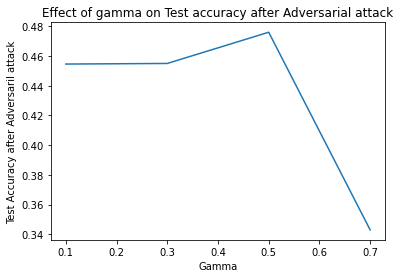

In [2]:
gamma = np.array([0.1, 0.3, 0.5, 0.7])
gam_before_adv = np.array([0.744,0.739,0.739,0.745])
gam_after_adv = np.array([0.4546,0.455,0.476,0.343])

import matplotlib.pyplot as plt
plt.plot(gamma, gam_after_adv)
plt.title('Effect of gamma on Test accuracy after Adversarial attack')
plt.xlabel('Gamma')
plt.ylabel('Test Accuracy after Adversaril attack')
plt.show()

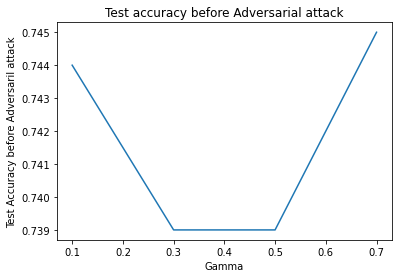

In [3]:
import matplotlib.pyplot as plt
plt.plot(gamma, gam_before_adv)
plt.title('Test accuracy before Adversarial attack')
plt.xlabel('Gamma')
plt.ylabel('Test Accuracy before Adversaril attack')
plt.show()

In [4]:
thetha = np.array([0.3,0.5,0.7,1])
thetha_before_adv = np.array([0.739,0.740,0.7632,0.744])
thetha_after_adv = np.array([0.521,0.503,0.4678,0.4546])

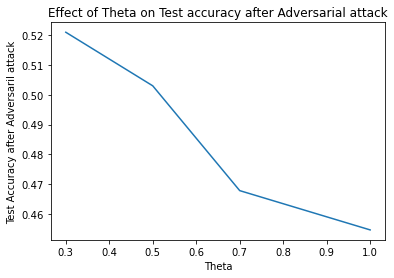

In [7]:
import matplotlib.pyplot as plt
plt.plot(thetha, thetha_after_adv)
plt.title('Effect of Theta on Test accuracy after Adversarial attack')
plt.xlabel('Theta')
plt.ylabel('Test Accuracy after Adversaril attack')
plt.show()

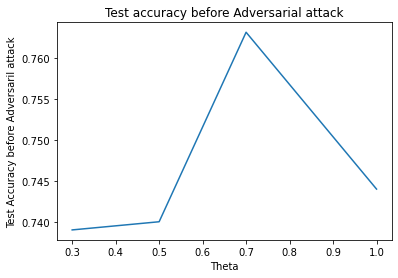

In [6]:
import matplotlib.pyplot as plt
plt.plot(thetha, thetha_before_adv)
plt.title('Test accuracy before Adversarial attack')
plt.xlabel('Theta')
plt.ylabel('Test Accuracy before Adversaril attack')
plt.show()

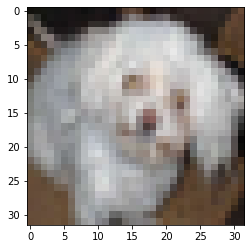

In [8]:
# Pick an image to display
## correct classification-1000
img_num = 1000
img = x_test[img_num]
img1 = x_test_adv[img_num]
# Show the image
plt.imshow(img)
plt.show()

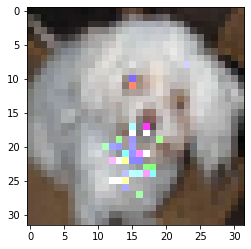

In [9]:
plt.imshow(img1)
plt.show()

In [12]:
# Evaluate the model on the adversarial image
preds_adv = model.predict(x_test_adv)
preds = model.predict(x_test)
# Get the class label and confidence score
class_label_adv = np.argmax(preds_adv, axis=1)
confidence_adv = np.max(preds_adv, axis=1)
class_label = np.argmax(preds, axis=1)
confidence = np.max(preds, axis=1)
print('Class Label Adversarial Image:', class_label_adv[img_num])
print('Class Label Image:', class_label[img_num])
print('Confidence Adversarial Image:', confidence_adv[img_num])
print('Class Confidence Image:', confidence[img_num])

Class Label Adversarial Image: 8
Class Label Image: 5
Confidence Adversarial Image: 0.43104503
Class Confidence Image: 0.9487856


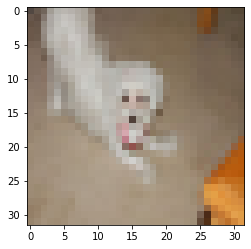

In [34]:
# Pick an image to display
## correct classification-1000
img_num = 1400
img = x_test[img_num]
img1 = x_test_adv[img_num]
# Show the image
plt.imshow(img)
plt.show()


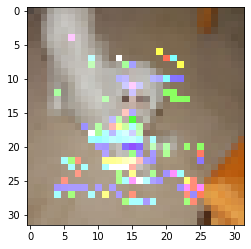

In [35]:
plt.imshow(img1)
plt.show()

In [36]:
# Evaluate the model on the adversarial image
preds_adv = model.predict(x_test_adv)
preds = model.predict(x_test)
# Get the class label and confidence score
class_label_adv = np.argmax(preds_adv, axis=1)
confidence_adv = np.max(preds_adv, axis=1)
class_label = np.argmax(preds, axis=1)
confidence = np.max(preds, axis=1)


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

# Get the class label name of the first image in the training set
#class_label = class_names[y_train[0][0]]
class_label_name = class_names[class_label[img_num]]
#class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

# Get the class label name of the first image in the training set
#class_label = class_names[y_train[0][0]]
class_label_name_adv = class_names[class_label_adv[img_num]]
print('Class Label Image:', class_label[img_num])
print('Class Label name before Adversarial:',class_label_name) 
print('Class Confidence Image:', confidence[img_num])# Output: 'frog'

print('Class Label Adversarial Image:', class_label_adv[img_num])
print('Class Label name after Adversarial:',class_label_name_adv)  
print('Confidence Adversarial Image:', confidence_adv[img_num])
# Output: 'frog'

Class Label Image: 3
Class Label name before Adversarial: cat
Class Confidence Image: 0.60162896
Class Label Adversarial Image: 6
Class Label name after Adversarial: frog
Confidence Adversarial Image: 0.41721043


In [22]:
#class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

# Get the class label name of the first image in the training set
#class_label = class_names[y_train[0][0]]
#class_label = class_names[class_label_adv[img_num]]
print(class_label)  # Output: 'frog'

truck
